# 5: End-to-End Workflow

**Question:** How does Sentinel-2 NDVI change from January to June 2023 over a small AOI, and is greenness different on higher ground?

| Step |  In this notebook |
|------|------------------|
| Find scenes by place, time, cloud cover |  Search Planetary Computer |
| Stream only a window | 1 COG | Signed `href` + HTTP range reads |
| Labeled cube (`time`, `y`, `x`) | `concat`, NDVI, `.sel` / `.isel` |
| CRS, clip, align DEM |  `clip_box`, `reproject_match` |
| Chunked lazy compute |  `chunks=`, `.persist()`, `.compute()` |



Clip first so only the window is streamed. Data stays in the cloud until a plot or write.




In [6]:
# STAC search, signed COG URLs, geospatial xarray, and plots
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rioxarray          # GeoTIFF/COG → xarray + .rio (CRS, clip, write)
import xarray as xr       # labeled cube (time, y, x)
import pystac_client      # search a STAC API
import planetary_computer # sign Planetary Computer asset URLs


## 1. STAC — find Sentinel-2 and a DEM tile

Metadata only. Same AOI as Lessons 1–2.


In [7]:
# Study area: northern Karnataka, India (same window as Lessons 1–2)
# bbox / CLIP order is always [min_lon, min_lat, max_lon, max_lat]
BBOX = [75.62, 16.20, 77.29, 17.47]
CLIP = (76.40, 16.75, 76.55, 16.90)  # small AOI so later reads stay workshop-sized

# Metadata only — no imagery is downloaded here
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1"
)

# Sentinel-2 L2A: analysis-ready surface reflectance
s2_search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=list(CLIP),
    datetime="2023-01-01/2023-06-30",
    max_items=5,
    query={"eo:cloud_cover": {"lt": 15}},  # keep mostly clear scenes
)
# Unsigned hrefs return HTTP 403 on Planetary Computer
items = [planetary_computer.sign(it) for it in s2_search.items()]
items = sorted(items, key=lambda it: it.datetime)

# Same tile can appear twice (original + reprocessed). One item per day
# keeps the time axis unique for later .sel / plots.
by_day = {}
for it in items:
    by_day[it.datetime.date()] = it
items = sorted(by_day.values(), key=lambda it: it.datetime)

# Copernicus DEM GLO-30: one ~1° COG tile covers this CLIP
dem_search = catalog.search(
    collections=["cop-dem-glo-30"],
    bbox=list(CLIP),
    max_items=1,
)
dem_item = planetary_computer.sign(list(dem_search.items())[0])

print(f"Sentinel-2 scenes: {len(items)}")
for it in items:
    cc = it.properties.get("eo:cloud_cover")
    print(f"  {it.datetime.date()}  cloud={cc:.1f}%  {it.id}")
print("DEM tile:", dem_item.id)


Sentinel-2 scenes: 3
  2023-05-26  cloud=0.0%  S2A_MSIL2A_20230526T051651_R062_T43QFU_20230526T114329
  2023-06-05  cloud=12.3%  S2A_MSIL2A_20230605T051651_R062_T43QFU_20230605T105024
  2023-06-20  cloud=0.1%  S2B_MSIL2A_20230620T051659_R062_T43QFU_20230620T112809
DEM tile: Copernicus_DSM_COG_10_N16_00_E076_00_DEM


## 2. COG — inspect one scene

Open the first red-band COG. Header first; no full-scene download. List a few assets so the STAC item is visible.


In [8]:
# First scene: list STAC assets (B04 = red, B08 = NIR, visual = RGB, …)
item0 = items[0]
print("Assets (sample):", list(item0.assets)[:12])

# chunks= → Dask array. Opening a COG reads the header (CRS, size), not pixels.
red0 = rioxarray.open_rasterio(item0.assets["B04"].href, chunks={"x": 1024, "y": 1024})
print("CRS:", red0.rio.crs)           # UTM for this Sentinel-2 tile
print("Bounds:", red0.rio.bounds())
print("Shape:", red0.shape)           # full tile; we clip in the next step
print("Dask?", type(red0.data))
red0


Assets (sample): ['AOT', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B11', 'B12']
CRS: EPSG:32643
Bounds: (600000.0, 1790220.0, 709800.0, 1900020.0)
Shape: (1, 10980, 10980)
Dask? <class 'dask.array.core.Array'>


<xarray.DataArray (band: 1, y: 10980, x: 10980)> Size: 241MB
dask.array<open_rasterio-e1c41c7368bf01302e389e123300217f<this-array>, shape=(1, 10980, 10980), dtype=uint16, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 88kB 6e+05 6e+05 6e+05 ... 7.098e+05 7.098e+05
  * y            (y) float64 88kB 1.9e+06 1.9e+06 1.9e+06 ... 1.79e+06 1.79e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     0
    scale_factor:   1.0
    add_offset:     0.0

## 3. rioxarray — clip the AOI and align the DEM 

Open red and NIR per date with `chunks=`. `clip_box` keeps the graph on the window. The 30 m DEM is warped onto the Sentinel-2 grid with `reproject_match`.


In [9]:
def open_scene(item, clip, chunks):
    """One STAC item → Dataset of clipped B04/B08, with a time coordinate."""
    bands = {}
    for bid in ("B04", "B08"):
        # Dask-backed COG; pixels stay in the cloud until compute/plot
        da = rioxarray.open_rasterio(item.assets[bid].href, chunks=chunks)
        da = da.squeeze("band", drop=True)  # single-band file still has band=1
        # lon/lat box → only intersecting tiles are in the graph
        da = da.rio.clip_box(
            minx=clip[0], miny=clip[1], maxx=clip[2], maxy=clip[3], crs="EPSG:4326"
        )
        bands[bid] = da
    ds = xr.Dataset(bands)
    # xarray time works best as timezone-naive timestamps
    t = pd.Timestamp(item.datetime)
    if t.tzinfo is not None:
        t = t.tz_convert("UTC").tz_localize(None)
    ds = ds.assign_coords(time=t)
    return ds


chunks = {"x": 1024, "y": 1024}  # close to typical COG tile size
scenes = [open_scene(it, CLIP, chunks) for it in items]
template = scenes[0]["B04"]  # S2 grid we will warp the DEM onto

# DEM is ~30 m / EPSG:4326; Sentinel-2 is 10 m / UTM — align before combining
dem = rioxarray.open_rasterio(dem_item.assets["data"].href, chunks=chunks)
dem = dem.squeeze("band", drop=True)
dem = dem.rio.clip_box(
    minx=CLIP[0], miny=CLIP[1], maxx=CLIP[2], maxy=CLIP[3], crs="EPSG:4326"
)
dem_on_s2 = dem.rio.reproject_match(template)  # same CRS, bounds, pixel size
dem_on_s2.name = "dem"

print("Scene grid:", template.shape, template.rio.crs)
print("DEM on S2:", dem_on_s2.shape, dem_on_s2.rio.crs)
print("Elevation (m):", float(dem_on_s2.min()), "->", float(dem_on_s2.max()))


Scene grid: (1673, 1612) EPSG:32643
DEM on S2: (1673, 1612) EPSG:32643
Elevation (m): 411.5813903808594 -> 506.4533996582031


## 4. xarray — cube, NDVI, select by date 

`concat` along `time`. NDVI is named arithmetic. `.isel` / `.sel` pick dates without axis indexes.


In [10]:
# Stack scenes into one Dataset: dims time, y, x
cube = xr.concat(scenes, dim="time").sortby("time")
# Safety: drop any remaining duplicate timestamps
_, unique_idx = np.unique(cube["time"].values, return_index=True)
cube = cube.isel(time=sorted(unique_idx.tolist()))

# DEM is 2-D (y, x); xarray broadcasts it across time
cube["dem"] = dem_on_s2
# NDVI = (NIR - red) / (NIR + red). Still lazy (Dask graph).
cube["ndvi"] = (cube["B08"] - cube["B04"]) / (cube["B08"] + cube["B04"])

print("Cube dims:", dict(cube.sizes))
print("Times:", [str(t)[:10] for t in cube["time"].values])
print("NDVI still Dask?", type(cube["ndvi"].data))

# .isel = by position; .sel = by coordinate label
first = cube.isel(time=0)
date0 = str(cube["time"].values[0])[:10]
red_sel = cube["B04"].isel(time=0)
print("First date:", date0, "B04 shape:", red_sel.shape)
cube


Cube dims: {'time': 3, 'y': 1673, 'x': 1612}
Times: ['2023-05-26', '2023-06-05', '2023-06-20']
NDVI still Dask? <class 'dask.array.core.Array'>
First date: 2023-05-26 B04 shape: (1673, 1612)


<xarray.Dataset> Size: 108MB
Dimensions:      (time: 3, y: 1673, x: 1612)
Coordinates:
  * x            (x) float64 13kB 6.491e+05 6.491e+05 ... 6.652e+05 6.652e+05
  * y            (y) float64 13kB 1.869e+06 1.869e+06 ... 1.852e+06 1.852e+06
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 24B 2023-05-26T05:16:51.024000 ... 202...
Data variables:
    B04          (time, y, x) uint16 16MB dask.array<chunksize=(1, 1009, 209), meta=np.ndarray>
    B08          (time, y, x) uint16 16MB dask.array<chunksize=(1, 1009, 209), meta=np.ndarray>
    dem          (y, x) float32 11MB nan nan nan nan nan ... nan nan nan nan nan
    ndvi         (time, y, x) float64 65MB dask.array<chunksize=(1, 1009, 209), meta=np.ndarray>

## 5. Dask — persist, reduce

`.persist()` keeps the clipped NDVI in memory. Spatial mean → one value per date. Elevation is 2-D and broadcasts across time.


In [11]:
# Run the graph once and keep clipped NDVI chunks in memory (no COG re-read)
ndvi = cube["ndvi"].persist()

# Spatial mean → one NDVI value per date (still lazy until .compute)
ts = ndvi.mean(dim=("y", "x"))
print("Time series still lazy:", type(ts.data))
ts_c = ts.compute()

# Share of pixels that look like vegetation
veg_frac = (ndvi > 0.3).mean(dim=("y", "x")).compute()
# 2-D DEM mask broadcasts over time automatically
high = cube["dem"] > 500
ndvi_high = ndvi.where(high).mean(dim=("y", "x")).compute()

print(ts_c)
print("Veg fraction NDVI>0.3:", np.round(veg_frac.values.astype(float), 3))
print("Mean NDVI where DEM>500 m:", np.round(ndvi_high.values.astype(float), 3))


Time series still lazy: <class 'dask.array.core.Array'>
<xarray.DataArray 'ndvi' (time: 3)> Size: 24B
array([0.16691966, 0.17995856, 0.12989692])
Coordinates:
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 24B 2023-05-26T05:16:51.024000 ... 202...
Veg fraction NDVI>0.3: [0.13  0.119 0.074]
Mean NDVI where DEM>500 m: [0.081 0.079 0.068]


## 6. Maps and time series

Context RGB (Lesson 1 `visual` asset), NDVI, elevation, and the greenness curve.


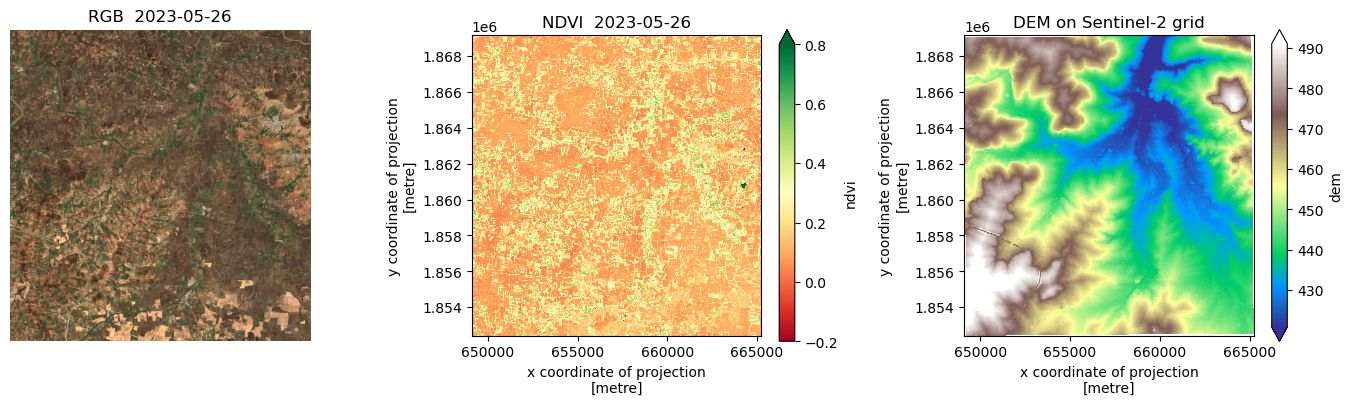

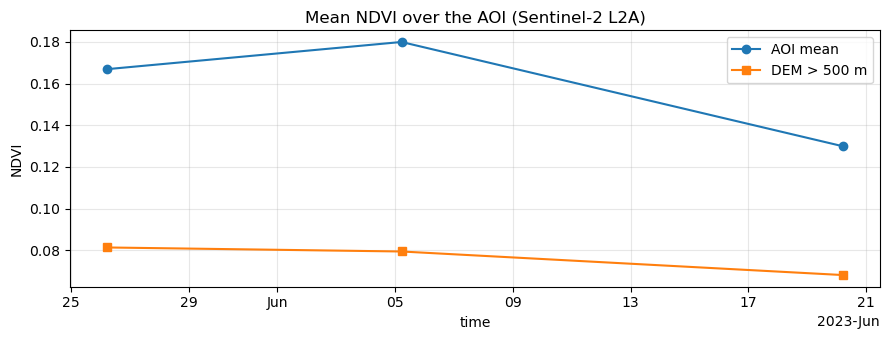

In [12]:
# RGB preview COG (B04/B03/B02 already stacked). Same CLIP window.
visual = rioxarray.open_rasterio(item0.assets["visual"].href, chunks=chunks)
visual = visual.rio.clip_box(
    minx=CLIP[0], miny=CLIP[1], maxx=CLIP[2], maxy=CLIP[3], crs="EPSG:4326"
).load()
# matplotlib wants (rows, cols, 3); stretch if the values are not 0–255
rgb = np.moveaxis(visual.values, 0, -1)
if rgb.dtype != np.uint8:
    valid = rgb[rgb > 0]
    hi = np.percentile(valid, 98) if valid.size else 1
    rgb = np.clip(rgb / hi, 0, 1)

ndvi0 = ndvi.isel(time=0)  # first date; persist means this is already in memory

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(rgb)
axes[0].set_title(f"RGB  {date0}")
axes[0].axis("off")

ndvi0.plot(ax=axes[1], cmap="RdYlGn", vmin=-0.2, vmax=0.8)
axes[1].set_title(f"NDVI  {date0}")
axes[1].set_aspect("equal")

cube["dem"].plot(ax=axes[2], cmap="terrain", robust=True)
axes[2].set_title("DEM on Sentinel-2 grid")
axes[2].set_aspect("equal")
plt.tight_layout()
plt.show()

# Greenness over time: whole AOI vs higher ground
fig, ax = plt.subplots(figsize=(9, 3.5))
ts_c.plot(ax=ax, marker="o", label="AOI mean")
ndvi_high.plot(ax=ax, marker="s", label="DEM > 500 m")
ax.set_ylabel("NDVI")
ax.set_title("Mean NDVI over the AOI (Sentinel-2 L2A)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 7. Write outputs

`.rio.to_raster()` and `.to_netcdf()` trigger compute for what they write.


In [13]:
# Writes trigger compute for that layer only (not the unused bands)
out = Path("output")
out.mkdir(parents=True, exist_ok=True)

# 2-D slices → GeoTIFF (tiled ≈ COG-friendly)
ndvi0.rio.to_raster(out / f"ndvi_{date0}.tif", compress="deflate", tiled=True)
cube["dem"].rio.to_raster(out / "dem_on_s2.tif", compress="deflate", tiled=True)
# Full cube (time + DEM) → NetCDF
cube[["ndvi", "dem"]].to_netcdf(out / "karnataka_ndvi_dem.nc")

print("Wrote", (out / f"ndvi_{date0}.tif").resolve())
print("Wrote", (out / "dem_on_s2.tif").resolve())
print("Wrote", (out / "karnataka_ndvi_dem.nc").resolve())


Wrote /Users/amanchaudhary/Desktop/foss4g/scalable-raster-analytics-course/notebooks/output/ndvi_2023-05-26.tif
Wrote /Users/amanchaudhary/Desktop/foss4g/scalable-raster-analytics-course/notebooks/output/dem_on_s2.tif
Wrote /Users/amanchaudhary/Desktop/foss4g/scalable-raster-analytics-course/notebooks/output/karnataka_ndvi_dem.nc
